In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta


sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [9]:
df = pd.read_csv('sales_data_sample (1).csv', encoding='latin1')

In [25]:
df.shape

(2823, 25)

In [24]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [23]:
print(df.isnull().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64


In [21]:
print(df.dtypes)

ORDERNUMBER                  int64
QUANTITYORDERED              int64
PRICEEACH                  float64
ORDERLINENUMBER              int64
SALES                      float64
ORDERDATE           datetime64[ns]
STATUS                      object
QTR_ID                       int64
MONTH_ID                     int64
YEAR_ID                      int64
PRODUCTLINE                 object
MSRP                         int64
PRODUCTCODE                 object
CUSTOMERNAME                object
PHONE                       object
ADDRESSLINE1                object
ADDRESSLINE2                object
CITY                        object
STATE                       object
POSTALCODE                  object
COUNTRY                     object
TERRITORY                   object
CONTACTLASTNAME             object
CONTACTFIRSTNAME            object
DEALSIZE                    object
dtype: object


In [19]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

print("Updated Data Type for ORDERDATE:")
print(df['ORDERDATE'].dtype)

Updated Data Type for ORDERDATE:
datetime64[ns]


In [26]:
unique_customers = df['CUSTOMERNAME'].nunique()
print(f"Number of Unique Customers: {unique_customers}")

Number of Unique Customers: 92


In [27]:
reference_date = df['ORDERDATE'].max() + timedelta(days=1)

print("Reference Date Used for RFM Analysis:")
print(reference_date)

Reference Date Used for RFM Analysis:
2005-06-01 00:00:00


In [36]:
rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': lambda x: (reference_date - x.max()).days,
    'ORDERNUMBER': 'nunique',
    'SALES': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print("RFM Table Preview:\n")
print(rfm.head())
print("\n" + "-"*100)

print("\nRFM Descriptive Statistics:\n")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM Table Preview:

              CUSTOMERNAME  Recency  Frequency   Monetary
0           AV Stores, Co.      196          3  157807.81
1             Alpha Cognac       65          3   70488.44
2       Amica Models & Co.      265          2   94117.26
3  Anna's Decorations, Ltd       84          4  153996.13
4        Atelier graphique      188          3   24179.96

----------------------------------------------------------------------------------------------------

RFM Descriptive Statistics:

          Recency  Frequency       Monetary
count   92.000000  92.000000      92.000000
mean   182.826087   3.336957  109050.313587
std    131.420524   2.924986  110308.612808
min      1.000000   1.000000    9129.350000
25%     81.250000   2.000000   70129.432500
50%    186.000000   3.000000   86522.610000
75%    230.250000   3.000000  120575.875000
max    509.000000  26.000000  912294.110000


In [38]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4, 3, 2, 1]
)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1, 2, 3, 4]
)
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)
print("RFM Scores Preview:")
print(rfm.head())

RFM Scores Preview:
              CUSTOMERNAME  Recency  Frequency   Monetary  R_Score  F_Score  \
0           AV Stores, Co.      196          3  157807.81        2        2   
1             Alpha Cognac       65          3   70488.44        4        2   
2       Amica Models & Co.      265          2   94117.26        1        1   
3  Anna's Decorations, Ltd       84          4  153996.13        3        4   
4        Atelier graphique      188          3   24179.96        2        2   

   M_Score RFM_Segment  
0        4         224  
1        2         422  
2        3         113  
3        4         344  
4        1         221  


In [40]:
def customer_segment(row):
    if (
        row['R_Score'] == 4 and
        row['F_Score'] == 4 and
        row['M_Score'] == 4
    ):
        return 'Champions'
    elif (
        row['R_Score'] >= 3 and
        row['F_Score'] >= 3
    ):
        return 'Loyal'
    elif (
        row['R_Score'] == 1 and
        row['F_Score'] >= 3 and
        row['M_Score'] >= 3
    ):
        return 'At Risk'
    elif (
        row['R_Score'] == 2 and
        row['F_Score'] >= 2
    ):
        return 'Needs Attention'
    elif (
        row['R_Score'] == 1 and
        row['F_Score'] == 1 and
        row['M_Score'] == 1
    ):
        return 'Lost'
    else:
        return 'Potential'


rfm['Customer Segment'] = rfm.apply(customer_segment, axis=1)
print("\nCustomer Segment Distribution:\n")
print(rfm['Customer Segment'].value_counts())


Customer Segment Distribution:

Customer Segment
Potential          27
Loyal              26
Needs Attention    18
Lost               11
Champions           9
At Risk             1
Name: count, dtype: int64


In [43]:
segment_summary = rfm.groupby('Customer Segment').agg({
    'CUSTOMERNAME': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()
segment_summary.columns = [
    'Segment Name',
    'Customer Count',
    'Average Recency',
    'Average Frequency',
    'Average Monetary'
]
segment_summary = segment_summary.sort_values(
    by='Average Monetary',
    ascending=False
)
segment_summary['Average Monetary'] = (
    segment_summary['Average Monetary']
    .round(2)
)


print("Segment Summary Table:\n")
print(segment_summary)

Segment Summary Table:

      Segment Name  Customer Count  Average Recency  Average Frequency  \
1        Champions               9        19.444444           8.111111   
0          At Risk               1       456.000000           3.000000   
3            Loyal              26       101.769231           3.423077   
4  Needs Attention              18       201.333333           3.111111   
5        Potential              27       220.518519           2.407407   
2             Lost              11       360.454545           1.909091   

   Average Monetary  
1         290097.74  
0         142874.25  
3         111308.43  
4          99222.93  
5          74918.75  
2          52366.99  


In [45]:
#Champions
print("\n" + "="*80)
print("SEGMENT: Champions")
print("="*80)

print("""
Behavior:
Highly engaged customers with recent purchases,
high order frequency, and strong monetary contribution.

Business Meaning:
These are the company's most valuable customers and
core revenue drivers.

Marketing Strategy:
- Offer VIP loyalty programs
- Provide early access to new products
- Deliver personalized recommendations
- Encourage referrals and advocacy

Retention Strategy:
Maintain premium customer experience and build
long-term relationships through exclusivity.
""")


# Loyal Customers
print("\n" + "="*80)
print("SEGMENT: Loyal")
print("="*80)

print("""
Behavior:
Consistent and active customers with strong engagement.

Business Meaning:
Reliable customer base contributing steady revenue.

Marketing Strategy:
- Upsell complementary products
- Offer loyalty rewards
- Provide personalized email campaigns

Retention Strategy:
Increase engagement frequency through targeted promotions.
""")


# At Risk
print("\n" + "="*80)
print("SEGMENT: At Risk")
print("="*80)

print("""
Behavior:
Previously high-value customers who have not
purchased recently.

Business Meaning:
Potential revenue loss if customers churn permanently.

Marketing Strategy:
- Launch win-back campaigns
- Offer personalized discounts
- Send reactivation emails

Retention Strategy:
Re-engage customers before complete churn occurs.
""")


# Needs Attention
print("\n" + "="*80)
print("SEGMENT: Needs Attention")
print("="*80)

print("""
Behavior:
Moderately active customers showing declining engagement.

Business Meaning:
These customers may transition into churn risk.

Marketing Strategy:
- Increase engagement through promotions
- Recommend trending products
- Improve communication frequency

Retention Strategy:
Monitor activity patterns and intervene early.
""")


# Lost Customers
print("\n" + "="*80)
print("SEGMENT: Lost")
print("="*80)

print("""
Behavior:
Inactive customers with low purchase activity and low spending.

Business Meaning:
Low current value but potential for reactivation.

Marketing Strategy:
- Offer strong discount campaigns
- Send reactivation offers
- Conduct customer feedback surveys

Retention Strategy:
Attempt low-cost reactivation before removing from
active marketing campaigns.
""")


SEGMENT: Champions

Behavior:
Highly engaged customers with recent purchases,
high order frequency, and strong monetary contribution.

Business Meaning:
These are the company's most valuable customers and
core revenue drivers.

Marketing Strategy:
- Offer VIP loyalty programs
- Provide early access to new products
- Deliver personalized recommendations
- Encourage referrals and advocacy

Retention Strategy:
Maintain premium customer experience and build
long-term relationships through exclusivity.


SEGMENT: Loyal

Behavior:
Consistent and active customers with strong engagement.

Business Meaning:
Reliable customer base contributing steady revenue.

Marketing Strategy:
- Upsell complementary products
- Offer loyalty rewards
- Provide personalized email campaigns

Retention Strategy:
Increase engagement frequency through targeted promotions.


SEGMENT: At Risk

Behavior:
Previously high-value customers who have not
purchased recently.

Business Meaning:
Potential revenue loss if custo

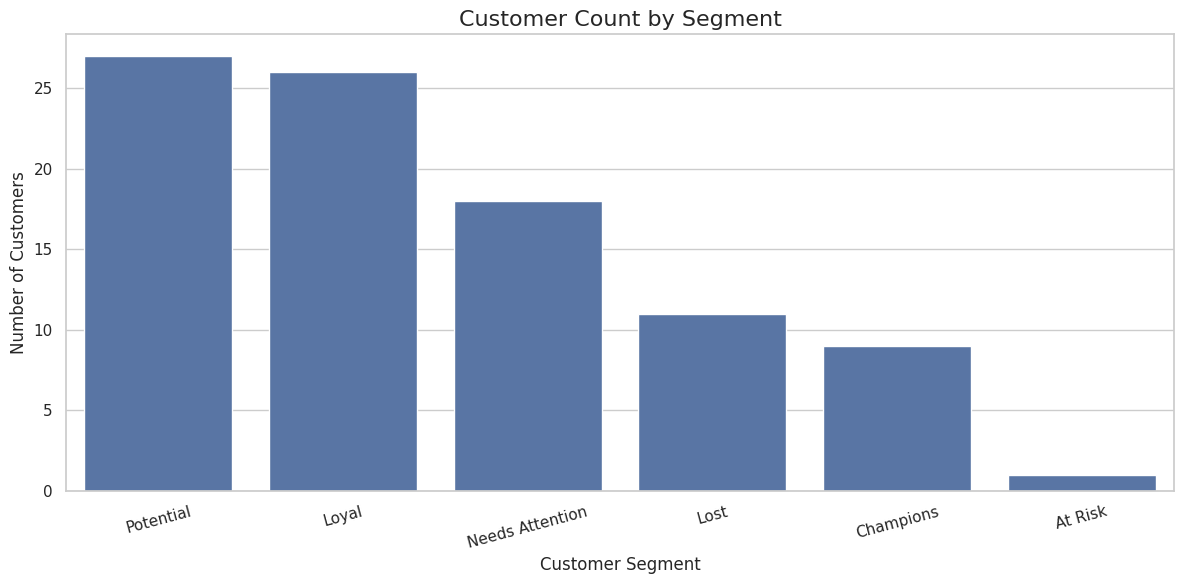

In [46]:
segment_counts = (
    rfm['Customer Segment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = ['Segment', 'Count']

plt.figure(figsize=(12, 6))

sns.barplot(
    data=segment_counts,
    x='Segment',
    y='Count'
)

plt.title('Customer Count by Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

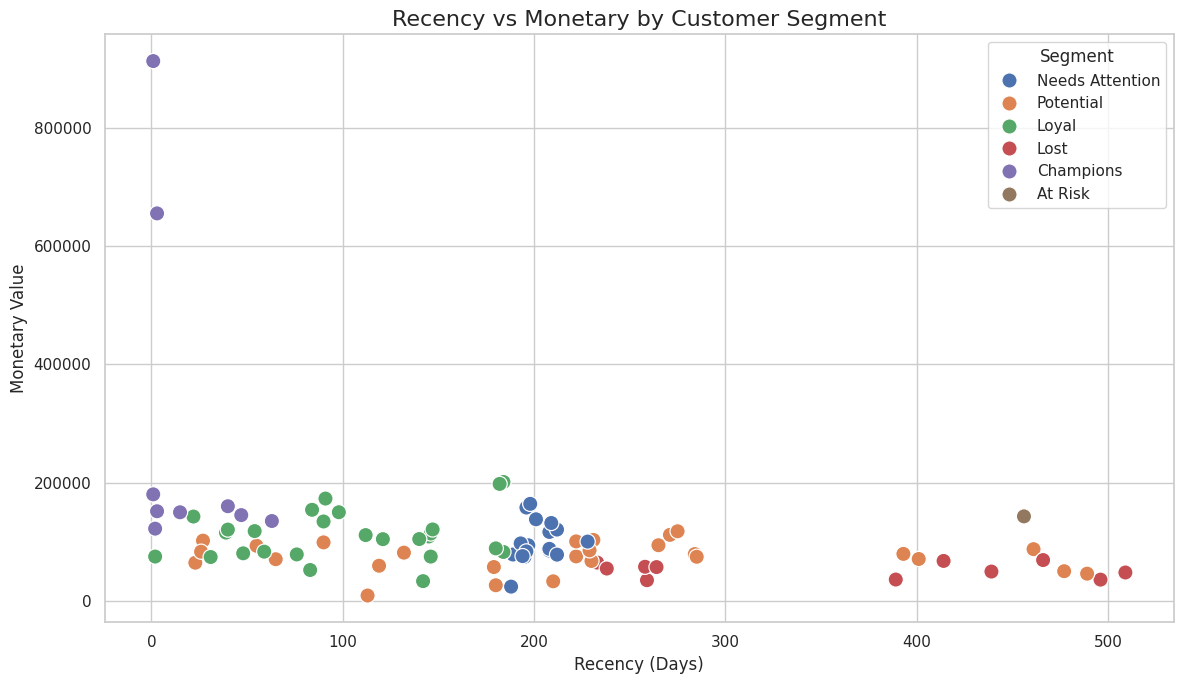

In [47]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Customer Segment',
    s=120
)

plt.title('Recency vs Monetary by Customer Segment', fontsize=16)
plt.xlabel('Recency (Days)', fontsize=12)
plt.ylabel('Monetary Value', fontsize=12)

plt.legend(title='Segment')

plt.tight_layout()
plt.show()

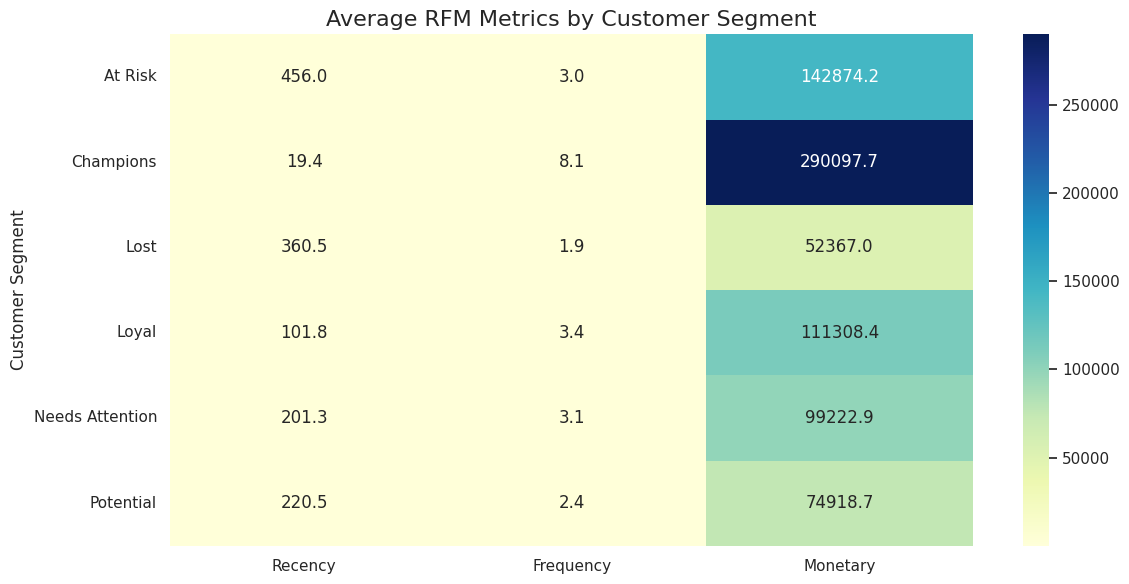

In [48]:
heatmap_data = rfm.groupby('Customer Segment')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Average RFM Metrics by Customer Segment', fontsize=16)

plt.tight_layout()
plt.show()


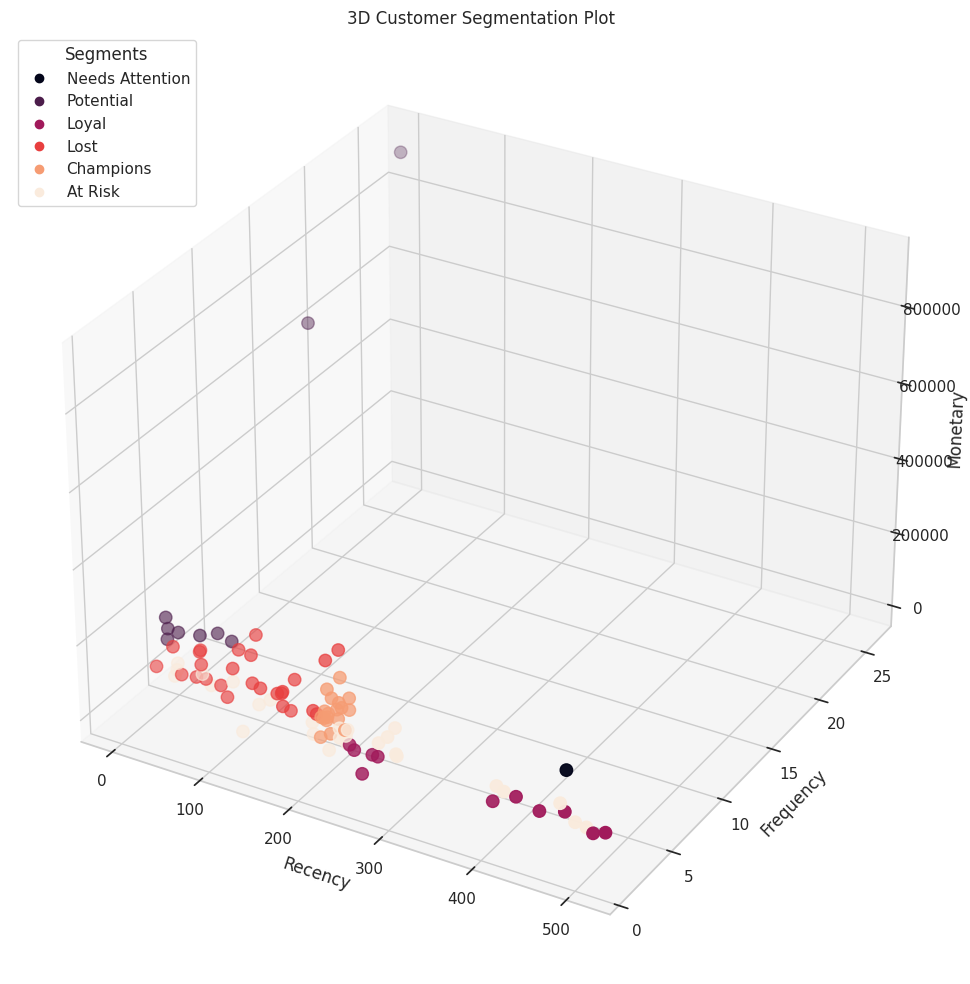

In [54]:
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(14, 10))

ax = fig.add_subplot(111, projection='3d')

# Create category codes for segments
rfm['Segment_Code'] = (
    rfm['Customer Segment']
    .astype('category')
    .cat.codes
)

# Create scatter plot
scatter = ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Segment_Code'],
    s=80
)

# Axis labels
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')

# Title
ax.set_title('3D Customer Segmentation Plot')

# Create custom legend
segment_labels = rfm['Customer Segment'].unique()

legend_elements = scatter.legend_elements()[0]

ax.legend(
    legend_elements,
    segment_labels,
    title='Segments',
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [55]:
final_report = rfm[[
    'CUSTOMERNAME',
    'Recency',
    'Frequency',
    'Monetary',
    'R_Score',
    'F_Score',
    'M_Score',
    'RFM_Segment',
    'Customer Segment'
]]

# Export to CSV
final_report.to_csv(
    'rfm_customer_segmentation_report.csv',
    index=False
)